<a href="https://colab.research.google.com/gist/Hadri2T/98f809f6d183dd10aa5f0d3cd0ebbc99/2_semi_supervise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BrainScanAI — Notebook 2 : approche semi-supervisée

**Le point de départ.** Le notebook 1 a produit deux jeux de données, gardés strictement séparés :
- un jeu **fortement labellisé** : 96 images annotées par des radiologues, découpées en 67 images de train et 29 de test ;
- un jeu **faiblement labellisé** : 1 214 images étiquetées automatiquement par clustering, avec une qualité estimée à 88 %.

**La question de ce notebook.** Les 1 214 images sans annotation humaine permettent-elles de construire un meilleur modèle que les 96 images expertes seules ?

**Le protocole**, qui suit la consigne du projet :

| Modèle | Entraînement | Ce qu'il mesure |
| --- | --- | --- |
| **B0 — faible seul** | Les 1 214 labels faibles | Que vaut un modèle entraîné sans aucun label humain ? |
| **B — semi-supervisé** | B0, dont l'entraînement est **poursuivi** sur les 67 images fortes | Le préentraînement apporte-t-il quelque chose ? |
| **A — supervisé (référence)** | Les 67 images fortes, depuis zéro | La référence à battre |
| **C — semi-supervisé filtré** | Comme B, mais en ne préentraînant que sur les labels faibles les plus sûrs | Vaut-il mieux beaucoup de labels bruités ou moins de labels fiables ? |

La comparaison qui répond au projet est **A contre B**, sur les mêmes 29 images de test, qu'aucun modèle n'a jamais vues.

## 1. Environnement

Ce notebook fonctionne **sur Google Colab comme en local**. La cellule ci-dessous détecte l'environnement et règle les chemins en conséquence.

**Sur Colab**, elle monte Google Drive et décompresse le dataset dans le disque temporaire de la machine (`/content`), bien plus rapide à lire que Drive. Il faut donc avoir déposé dans un dossier `BrainScanAI` de ton Drive :
- `mri_dataset_brain_cancer_oc.zip` (les images) ;
- `inventaire_images.csv` et `labels_faibles.csv` (produits par le notebook 1).

Pense aussi à activer le GPU : **Exécution > Modifier le type d'exécution > T4 GPU**.

In [1]:
import copy
import random
import sys
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

try:
    import google.colab  # présent uniquement sur Colab
    SUR_COLAB = True
except ImportError:
    SUR_COLAB = False

if SUR_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE_DIR = Path("/content/drive/MyDrive/BrainScanAI")
    DATA_DIR = Path("/content/mri_dataset_brain_cancer_oc")
    if not DATA_DIR.exists():   # décompression une fois par session
        with zipfile.ZipFile(DRIVE_DIR / "mri_dataset_brain_cancer_oc.zip") as archive:
            archive.extractall("/content")
    INPUT_DIR = DRIVE_DIR
    OUTPUT_DIR = DRIVE_DIR / "outputs"
else:
    DATA_DIR = Path("../mri_dataset_brain_cancer_oc")
    INPUT_DIR = Path("../outputs")
    OUTPUT_DIR = Path("../outputs")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

device = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available()
          else "cpu")

# Graine fixée partout : deux exécutions donnent les mêmes résultats
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Colab : {SUR_COLAB} | calcul sur : {device}")
print(f"Données : {DATA_DIR} ({'trouvé' if DATA_DIR.exists() else 'MANQUANT'})")

Mounted at /content/drive
Colab : True | calcul sur : cuda
Données : /content/mri_dataset_brain_cancer_oc (trouvé)


## 2. Chargement des deux jeux de données

On recharge les fichiers produits par le notebook 1. Le découpage train / test du jeu fort a été **figé à l'étape 3** : on le réutilise tel quel, sans le retirer, sinon les images de test auraient pu servir au clustering.

La cellule vérifie aussi qu'**aucune image n'appartient aux deux jeux** : c'est la garantie que le jeu faible et le jeu fort restent séparés.

In [2]:
CLASSES = {"normal": 0, "cancer": 1}   # cancer = classe positive (celle qu'il ne faut pas rater)

inventaire = pd.read_csv(INPUT_DIR / "inventaire_images.csv")
faibles = pd.read_csv(INPUT_DIR / "labels_faibles.csv")

fort = inventaire[inventaire["subset"] == "avec_labels"]
fort_train = fort[fort["split_fort"] == "train"].reset_index(drop=True)
fort_test = fort[fort["split_fort"] == "test"].reset_index(drop=True)

# Garde-fou : le jeu faible et le jeu fort ne doivent partager aucune image
assert set(faibles["path"]).isdisjoint(set(fort["path"])), "Fuite entre jeu faible et jeu fort"

pd.DataFrame({
    "jeu faible": faibles["label_faible"].value_counts(),
    "fort (train)": fort_train["label"].value_counts(),
    "fort (test)": fort_test["label"].value_counts(),
}).fillna(0).astype(int)

,jeu faible,fort (train),fort (test)
cancer,789,35,15
normal,425,32,14


## 3. Préparation des images

**Taille retenue : 128×128.** Les images d'origine font 512×512, mais un CNN entraîné depuis zéro sur si peu de données n'a pas besoin d'autant de détail : une tumeur reste parfaitement visible à cette taille, et l'entraînement est 3 fois plus rapide qu'en 224.

**L'augmentation de données**, appliquée **uniquement à l'entraînement**, sert ici deux objectifs :

| Transformation | Pourquoi |
| --- | --- |
| Retournement horizontal | Une tumeur à gauche ou à droite reste une tumeur |
| Rotation de ±15° | Rend le modèle tolérant à l'inclinaison de la tête, et surtout **moins dépendant de l'orientation** — le biais identifié à l'étape 3 |
| Variation de luminosité et de contraste | Rend le modèle moins sensible au **type de séquence IRM**, l'autre biais identifié |

Avec seulement 67 images fortes, c'est aussi la meilleure protection contre le surapprentissage : le modèle ne voit jamais deux fois exactement la même image.

En évaluation, **aucune augmentation** : on mesure les performances sur les images telles qu'elles sont.

In [3]:
IMG_SIZE = 128

transform_train = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),      # une seule dimension de couleur : ce sont des IRM
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),                             # [0, 255] -> [0, 1], format (C, H, W)
])

transform_eval = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])


class MRIDataset(Dataset):
    """Lit les images sur le disque et renvoie (image transformée, label)."""

    def __init__(self, df, colonne_label, transform):
        self.paths = [DATA_DIR / chemin for chemin in df["path"]]
        self.labels = [CLASSES[label] for label in df[colonne_label]]
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        return self.transform(Image.open(self.paths[i])), self.labels[i]


print(f"{len(MRIDataset(fort_train, 'label', transform_eval))} images dans le train fort")

67 images dans le train fort


**Contrôle visuel.** La première ligne montre les images redimensionnées telles que le modèle les verra en évaluation ; la seconde, les mêmes après augmentation aléatoire. Il faut vérifier que les tumeurs restent lisibles en 128×128.

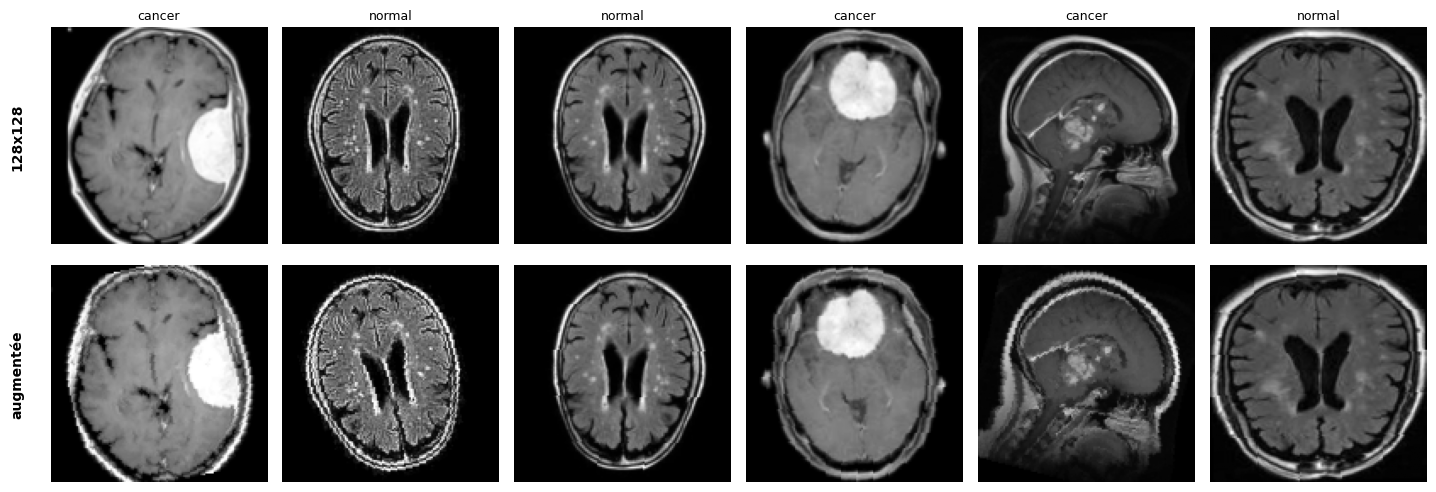

In [4]:
echantillon = fort_train.sample(6, random_state=0)

fig, axes = plt.subplots(2, len(echantillon), figsize=(2.4 * len(echantillon), 5.2))
for col, (_, ligne) in enumerate(echantillon.iterrows()):
    image = Image.open(DATA_DIR / ligne["path"])
    axes[0, col].imshow(transform_eval(image)[0], cmap="gray")
    axes[0, col].set_title(ligne["label"], fontsize=9)
    axes[1, col].imshow(transform_train(image)[0], cmap="gray")
    for ligne_axes in axes[:, col]:
        ligne_axes.axis("off")
axes[0, 0].text(-0.12, 0.5, "128x128", transform=axes[0, 0].transAxes, rotation=90,
                va="center", ha="right", fontweight="bold")
axes[1, 0].text(-0.12, 0.5, "augmentée", transform=axes[1, 0].transAxes, rotation=90,
                va="center", ha="right", fontweight="bold")
plt.tight_layout()
plt.show()

## 4. L'architecture du CNN

Le modèle est volontairement **petit**, parce qu'on n'a que 67 images labellisées : un gros réseau les mémoriserait au lieu d'apprendre.

```
Entrée : 1 canal, 128×128
 ├─ Bloc 1 : conv 3×3 (32 filtres) → batch norm → ReLU → max pooling 2×2   → 64×64
 ├─ Bloc 2 : conv 3×3 (64 filtres) → batch norm → ReLU → max pooling 2×2   → 32×32
 ├─ Bloc 3 : conv 3×3 (128 filtres) → batch norm → ReLU → max pooling 2×2  → 16×16
 ├─ Global average pooling                                                  → 128 valeurs
 ├─ Dropout (30 %)
 └─ Couche dense 128 → 2                                                    → cancer / normal
```

Le rôle de chaque brique :

| Brique | Rôle |
| --- | --- |
| **Convolution 3×3** | Détecte des motifs locaux. Les filtres sont partagés sur toute l'image, ce qui fait peu de paramètres et respecte la structure spatiale |
| **Batch normalization** | Recentre les valeurs à chaque couche, ce qui stabilise l'entraînement et laisse passer le gradient |
| **ReLU** | La non-linéarité. Sa pente vaut 1 du côté positif, donc le gradient traverse sans s'affaiblir |
| **Max pooling** | Divise la taille par deux, élargit la zone vue par les couches suivantes et rend le modèle tolérant aux petits décalages |
| **Global average pooling** | Remplace un aplatissement classique : il fait la moyenne de chaque carte, ce qui réduit énormément le nombre de paramètres du classifieur |
| **Dropout** | Désactive au hasard 30 % des valeurs pendant l'entraînement, pour éviter que le modèle ne s'appuie sur quelques détails |
| **Couche dense finale** | Le **classifieur** : elle combine les 128 caractéristiques en deux scores, un par classe |

Le nombre de filtres double à chaque bloc (32, 64, 128), au fur et à mesure que la taille de l'image diminue : c'est le schéma classique des CNN.

In [5]:
class PetitCNN(nn.Module):
    """Petit CNN : 3 blocs convolutifs pour extraire, une couche dense pour décider."""

    def __init__(self, n_classes=2, p_dropout=0.3):
        super().__init__()

        def bloc(canaux_entree, canaux_sortie):
            return nn.Sequential(
                nn.Conv2d(canaux_entree, canaux_sortie, kernel_size=3, padding=1),
                nn.BatchNorm2d(canaux_sortie),
                nn.ReLU(),
                nn.MaxPool2d(2),
            )

        self.extracteur = nn.Sequential(bloc(1, 32), bloc(32, 64), bloc(64, 128))
        self.classifieur = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),   # moyenne de chaque carte -> 128 valeurs
            nn.Flatten(),
            nn.Dropout(p_dropout),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        return self.classifieur(self.extracteur(x))


modele_test = PetitCNN()
n_params = sum(p.numel() for p in modele_test.parameters())
print(f"{n_params:,} paramètres".replace(",", " "))
print(modele_test)

93 378 paramètres
PetitCNN(
  (extracteur): Sequential(
    (0): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (classifieur): Sequential(
    (0): Adap

## 5. Entraînement et évaluation

**La fonction d'entraînement** suit la boucle classique du cours : passage avant, calcul de la perte, rétropropagation, mise à jour des poids.

- **Perte** : entropie croisée, la log-vraisemblance négative du chapitre 1.
- **Optimiseur** : Adam, une variante de la descente de gradient qui adapte le pas à chaque paramètre.
- **Arrêt anticipé** (*early stopping*) : plutôt que de fixer le nombre d'epochs à l'avance, on surveille le F1 sur un jeu de validation et on **garde les poids du meilleur moment**. Si le score ne progresse plus pendant plusieurs epochs, on arrête. C'est la protection la plus efficace contre le surapprentissage quand les données sont rares.

**L'évaluation** renvoie la probabilité de cancer pour chaque image, dont on tire les trois métriques du projet : accuracy, F1 sur la classe cancer, et AUC.

In [6]:
import time
from contextlib import contextmanager

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

TEMPS = {}


@contextmanager
def chrono(nom):
    """Mesure le temps d'une étape et le range dans TEMPS, pour le tableau de synthèse."""
    debut = time.perf_counter()
    yield
    TEMPS[nom] = time.perf_counter() - debut
    print(f"{nom} : {TEMPS[nom]:.1f} s")


@torch.no_grad()
def predire(model, dataset, batch_size=64):
    """Renvoie (vrais labels, probabilité prédite de cancer) pour tout le dataset."""
    model.eval()
    probas, vrais = [], []
    for x, y in DataLoader(dataset, batch_size=batch_size):
        scores = torch.softmax(model(x.to(device)), dim=1)[:, 1]   # colonne 1 = cancer
        probas.append(scores.cpu())
        vrais.append(y)
    return torch.cat(vrais).numpy(), torch.cat(probas).numpy()


def metriques(vrais, probas, seuil=0.5):
    """Les trois métriques du projet, avec le cancer comme classe positive."""
    predictions = (probas >= seuil).astype(int)
    return {
        "accuracy": accuracy_score(vrais, predictions),
        "f1": f1_score(vrais, predictions, zero_division=0),
        "auc": roc_auc_score(vrais, probas) if len(set(vrais)) > 1 else np.nan,
    }


def entrainer(model, train_ds, val_ds=None, epochs=40, batch_size=32, lr=1e-3, patience=8,
              poids_classes=None):
    """Entraîne le modèle. Avec un jeu de validation, applique l'arrêt anticipé sur le F1."""
    loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    optimiseur = torch.optim.Adam(model.parameters(), lr=lr)
    # poids_classes permet de rendre une erreur sur le cancer plus coûteuse qu'une fausse alerte
    poids = None if poids_classes is None else torch.tensor(poids_classes, dtype=torch.float, device=device)
    fonction_perte = nn.CrossEntropyLoss(weight=poids)

    meilleur = {"f1": -1.0, "poids": None, "epoch": 0}
    historique = []

    for epoch in range(1, epochs + 1):
        model.train()
        perte_totale = 0.0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimiseur.zero_grad()
            perte = fonction_perte(model(x), y)
            perte.backward()
            optimiseur.step()
            perte_totale += perte.item() * len(y)

        ligne = {"epoch": epoch, "perte_train": perte_totale / len(train_ds)}

        if val_ds is not None:
            scores = metriques(*predire(model, val_ds))
            ligne.update({f"val_{cle}": valeur for cle, valeur in scores.items()})
            if scores["f1"] > meilleur["f1"]:
                # Nouveau meilleur modèle : on met ses poids de côté
                meilleur = {"f1": scores["f1"], "poids": copy.deepcopy(model.state_dict()), "epoch": epoch}
            elif epoch - meilleur["epoch"] >= patience:
                historique.append(ligne)
                break

        historique.append(ligne)

    if meilleur["poids"] is not None:
        model.load_state_dict(meilleur["poids"])   # on restaure le meilleur moment

    return pd.DataFrame(historique)

## 6. Le protocole d'évaluation

C'est le point le plus important du notebook, parce qu'avec 96 images labellisées, un protocole bâclé produit des chiffres qui ne veulent rien dire.

**Deux niveaux :**

| Niveau | Données | À quoi ça sert |
| --- | --- | --- |
| **Validation croisée à 5 plis**, dans les 67 images du train | Le train fort, découpé en 5 parts | Régler les hyperparamètres et **comparer les modèles avec une marge d'incertitude** (moyenne et écart-type sur 5 mesures) |
| **Test final** | Les 29 images de test | Mesurer une seule fois, sur des images qu'aucune étape n'a jamais vues |

**Pourquoi la validation croisée est indispensable ici.** Avec 29 images de test, une seule erreur déplace l'accuracy de 3,5 points. Un écart de 0,04 entre deux modèles peut n'être qu'une image de différence, donc du hasard. Les 5 plis donnent un écart-type, qui dit si la différence observée est réelle.

Le découpage des plis est **stratifié** : chaque pli garde la même proportion de cancers et de normaux.

In [7]:
from sklearn.model_selection import StratifiedKFold

N_PLIS = 5


def validation_croisee(poids_initiaux=None, df=None, n_plis=N_PLIS, **hyperparams):
    """Entraîne et évalue le modèle sur n plis du train fort.

    poids_initiaux : état d'un modèle préentraîné sur les labels faibles (None = depuis zéro).
    """
    df = fort_train if df is None else df
    decoupage = StratifiedKFold(n_splits=n_plis, shuffle=True, random_state=SEED)
    resultats = []

    for pli, (idx_train, idx_val) in enumerate(decoupage.split(df, df["label"]), start=1):
        torch.manual_seed(SEED)              # même initialisation d'un modèle à l'autre
        model = PetitCNN().to(device)
        if poids_initiaux is not None:
            model.load_state_dict(poids_initiaux)   # on POURSUIT l'entraînement du modèle préentraîné

        train_ds = MRIDataset(df.iloc[idx_train], "label", transform_train)
        val_ds = MRIDataset(df.iloc[idx_val], "label", transform_eval)
        entrainer(model, train_ds, val_ds, **hyperparams)

        resultats.append({"pli": pli, **metriques(*predire(model, val_ds))})

    return pd.DataFrame(resultats)

## 7. Réglage des hyperparamètres

On teste une petite grille sur le **modèle supervisé**, par validation croisée. Chaque combinaison est évaluée sur les 5 plis, et on retient celle qui obtient le meilleur F1 moyen.

| Hyperparamètre | Valeurs testées | Ce que ça change |
| --- | --- | --- |
| **Taille de batch** | 16, 32 | Le nombre d'images vues avant chaque mise à jour des poids. Un petit batch donne un gradient plus bruité, ce qui aide parfois à généraliser ; un gros batch est plus stable et plus rapide |
| **Learning rate** | 0,001 et 0,0003 | La taille du pas de la descente de gradient. Trop grand, on enjambe le minimum ; trop petit, l'apprentissage traîne |
| **Nombre d'epochs** | Jusqu'à 40, avec arrêt anticipé | Déterminé automatiquement par l'arrêt anticipé, plutôt que fixé à l'avance |

La grille reste volontairement petite : avec 67 images, tester cinquante combinaisons reviendrait à choisir des réglages sur du bruit.

In [8]:
grille = [{"batch_size": b, "lr": lr} for b in [16, 32] for lr in [1e-3, 3e-4]]

lignes = []
for hyperparams in grille:
    scores = validation_croisee(**hyperparams, epochs=40)
    lignes.append({
        **hyperparams,
        "f1 moyen": scores["f1"].mean(),
        "f1 écart-type": scores["f1"].std(),
        "accuracy moyenne": scores["accuracy"].mean(),
        "auc moyenne": scores["auc"].mean(),
    })

resultats_grille = pd.DataFrame(lignes).sort_values("f1 moyen", ascending=False).reset_index(drop=True)
MEILLEURS_HP = {"batch_size": int(resultats_grille.loc[0, "batch_size"]),
                "lr": float(resultats_grille.loc[0, "lr"]),
                "epochs": 40}
print("Hyperparamètres retenus :", MEILLEURS_HP)
resultats_grille.round(3)

Hyperparamètres retenus : {'batch_size': 32, 'lr': 0.001, 'epochs': 40}


,batch_size,lr,f1 moyen,f1 écart-type,accuracy moyenne,auc moyenne
0,32,0.001,0.765,0.062,0.703,0.823
1,16,0.001,0.687,0.018,0.523,0.752
2,16,0.000,0.687,0.018,0.523,0.718
3,32,0.000,0.687,0.018,0.523,0.783


## 8. Préentraînement sur les labels faibles

C'est le premier temps de la consigne : entraîner un CNN sur le jeu faiblement labellisé.

Deux modèles sont préentraînés :
- **B0** sur les **1 214 labels faibles** ;
- **C0** sur les **70 % les plus sûrs** seulement.

**Comment on mesure la confiance d'un label faible.** Chaque image possède un `score_cancer`, calculé à l'étape 3 : la différence entre sa distance au centre du cluster « normal » et sa distance au centre du cluster « cancer ». Un score proche de zéro signifie que l'image est à la frontière entre les deux clusters, donc que son étiquette est douteuse. On garde les images dont la valeur absolue du score est la plus élevée.

C'est la logique du **seuil de confiance** de la pseudo-labellisation : ne réutiliser que les prédictions dont le modèle est sûr, pour éviter la propagation des erreurs.

Ici pas de validation croisée : ce préentraînement ne touche pas au jeu fort, et son seul rôle est de fournir un point de départ aux modèles B et C.

In [9]:
PART_CONSERVEE = 0.70   # part des labels faibles gardés pour le modèle C

# Les labels faibles les plus sûrs : ceux dont le score est le plus éloigné de la frontière
limite = faibles["score_cancer"].abs().quantile(1 - PART_CONSERVEE)
faibles_surs = faibles[faibles["score_cancer"].abs() >= limite].reset_index(drop=True)

print(f"Jeu faible complet : {len(faibles)} images")
print(f"Jeu faible filtré  : {len(faibles_surs)} images (seuil sur |score| = {limite:.2f})")
faibles_surs["label_faible"].value_counts()

Jeu faible complet : 1214 images
Jeu faible filtré  : 850 images (seuil sur |score| = 3.47)


,count
label_faible,
cancer,505
normal,345


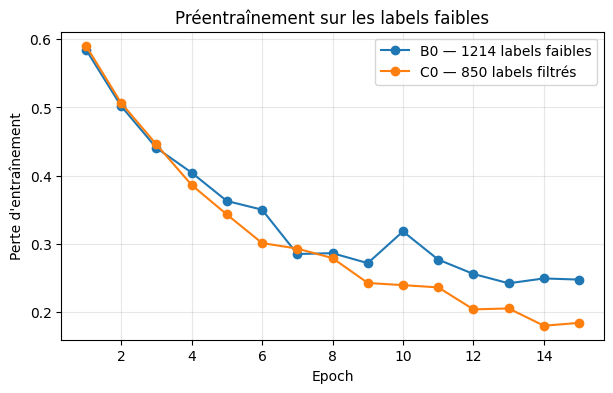

In [10]:
def pretrainer(df_faibles, epochs=15):
    """Entraîne un CNN depuis zéro sur des labels faibles et renvoie ses poids."""
    torch.manual_seed(SEED)
    model = PetitCNN().to(device)
    dataset = MRIDataset(df_faibles, "label_faible", transform_train)
    historique = entrainer(model, dataset, val_ds=None, epochs=epochs,
                           batch_size=MEILLEURS_HP["batch_size"], lr=MEILLEURS_HP["lr"])
    return model, historique


with chrono(f"Préentraînement B0 ({len(faibles)} labels faibles)"):
    modele_B0, hist_B0 = pretrainer(faibles)

with chrono(f"Préentraînement C0 ({len(faibles_surs)} labels filtrés)"):
    modele_C0, hist_C0 = pretrainer(faibles_surs)

poids_B0 = copy.deepcopy(modele_B0.state_dict())
poids_C0 = copy.deepcopy(modele_C0.state_dict())

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(hist_B0["epoch"], hist_B0["perte_train"], marker="o", label=f"B0 — {len(faibles)} labels faibles")
ax.plot(hist_C0["epoch"], hist_C0["perte_train"], marker="o", label=f"C0 — {len(faibles_surs)} labels filtrés")
ax.set_xlabel("Epoch")
ax.set_ylabel("Perte d'entraînement")
ax.set_title("Préentraînement sur les labels faibles")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

**Évaluation de B0 sur le jeu de test.** C'est le deuxième temps de la consigne : que vaut un modèle qui n'a jamais vu le moindre label humain ?

Attention à la lecture : ce modèle a appris à reproduire les clusters, et les clusters sont justes à environ 88 % seulement. Son plafond de performance est donc limité par la qualité de ses étiquettes.

In [11]:
test_ds = MRIDataset(fort_test, "label", transform_eval)

scores_B0 = metriques(*predire(modele_B0, test_ds))
scores_C0 = metriques(*predire(modele_C0, test_ds))

pd.DataFrame({"B0 (tous les labels faibles)": scores_B0,
              "C0 (labels faibles filtrés)": scores_C0}).round(3)

,B0 (tous les labels faibles),C0 (labels faibles filtrés)
accuracy,0.793,0.793
f1,0.800,0.750
auc,0.905,0.933


## 9. Les trois modèles en validation croisée

On compare maintenant les trois approches sur les **mêmes 5 plis** du train fort, avec les mêmes hyperparamètres. Seul le **point de départ** change :

- **A** part de poids aléatoires ;
- **B** part des poids de B0 ;
- **C** part des poids de C0.

C'est bien « le même modèle dont on poursuit l'entraînement », comme le demande la consigne.

In [12]:
comparaison = {}
for nom, poids in [("A — supervisé", None),
                   ("B — semi-supervisé", poids_B0),
                   ("C — semi-supervisé filtré", poids_C0)]:
    with chrono(f"Validation croisée — {nom}"):
        comparaison[nom] = validation_croisee(poids_initiaux=poids, **MEILLEURS_HP)

resume_cv = pd.DataFrame({
    nom: {
        "F1 moyen": scores["f1"].mean(),
        "F1 écart-type": scores["f1"].std(),
        "Accuracy moyenne": scores["accuracy"].mean(),
        "AUC moyenne": scores["auc"].mean(),
    }
    for nom, scores in comparaison.items()
}).T
resume_cv.round(3)

A — supervisé : terminé
B — semi-supervisé : terminé
C — semi-supervisé filtré : terminé


,F1 moyen,F1 écart-type,Accuracy moyenne,AUC moyenne
A — supervisé,0.765,0.062,0.703,0.823
B — semi-supervisé,0.925,0.068,0.908,0.948
C — semi-supervisé filtré,0.920,0.025,0.911,0.990


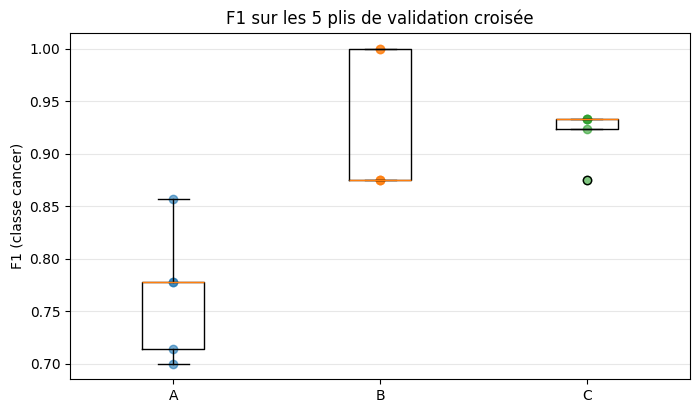

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.boxplot([scores["f1"] for scores in comparaison.values()],
           tick_labels=[nom.split(" — ")[0] for nom in comparaison])
for i, scores in enumerate(comparaison.values(), start=1):
    ax.scatter([i] * len(scores), scores["f1"], alpha=0.6)   # les 5 plis, un point chacun
ax.set_ylabel("F1 (classe cancer)")
ax.set_title(f"F1 sur les {N_PLIS} plis de validation croisée")
ax.grid(alpha=0.3, axis="y")
plt.show()

## 10. Entraînement final et évaluation sur le jeu de test

Les modèles sont réentraînés sur **l'intégralité des 67 images** du train fort, puis évalués **une seule fois** sur les 29 images de test.

Pour l'arrêt anticipé, on met 20 % du train de côté comme jeu de validation interne : le test reste ainsi totalement inutilisé jusqu'à la mesure finale.

In [14]:
from sklearn.model_selection import train_test_split

# Jeu de validation interne, uniquement pour l'arrêt anticipé
sous_train, sous_val = train_test_split(fort_train, test_size=0.2,
                                        stratify=fort_train["label"], random_state=SEED)

modeles_finaux, resultats_test = {}, {}
for nom, poids in [("A — supervisé", None),
                   ("B — semi-supervisé", poids_B0),
                   ("C — semi-supervisé filtré", poids_C0)]:
    torch.manual_seed(SEED)
    model = PetitCNN().to(device)
    if poids is not None:
        model.load_state_dict(poids)
    with chrono(f"Entraînement final — {nom}"):
        entrainer(model,
                  MRIDataset(sous_train, "label", transform_train),
                  MRIDataset(sous_val, "label", transform_eval),
                  **MEILLEURS_HP)
    modeles_finaux[nom] = model
    vrais, probas = predire(model, test_ds)
    resultats_test[nom] = {**metriques(vrais, probas), "probas": probas, "vrais": vrais}

tableau_test = pd.DataFrame({
    nom: {cle: valeur for cle, valeur in scores.items() if cle in ["accuracy", "f1", "auc"]}
    for nom, scores in resultats_test.items()
}).T
tableau_test.loc["B0 — faible seul"] = scores_B0
tableau_test.round(3)

,accuracy,f1,auc
A — supervisé,0.724,0.765,0.810
B — semi-supervisé,0.862,0.857,0.905
C — semi-supervisé filtré,0.931,0.929,0.952
B0 — faible seul,0.793,0.800,0.905


## 11. Analyse des performances

Trois lectures complémentaires :
- la **matrice de confusion**, qui sépare les types d'erreurs. En médecine, les deux colonnes n'ont pas le même poids : un **faux négatif** est une tumeur manquée, un **faux positif** une fausse alerte qu'un radiologue lèvera ;
- la **courbe ROC**, qui montre le compromis entre détection et fausses alertes pour tous les seuils possibles. L'AUC en est l'aire ;
- l'**affichage des erreurs**, pour comprendre sur quoi le modèle se trompe.

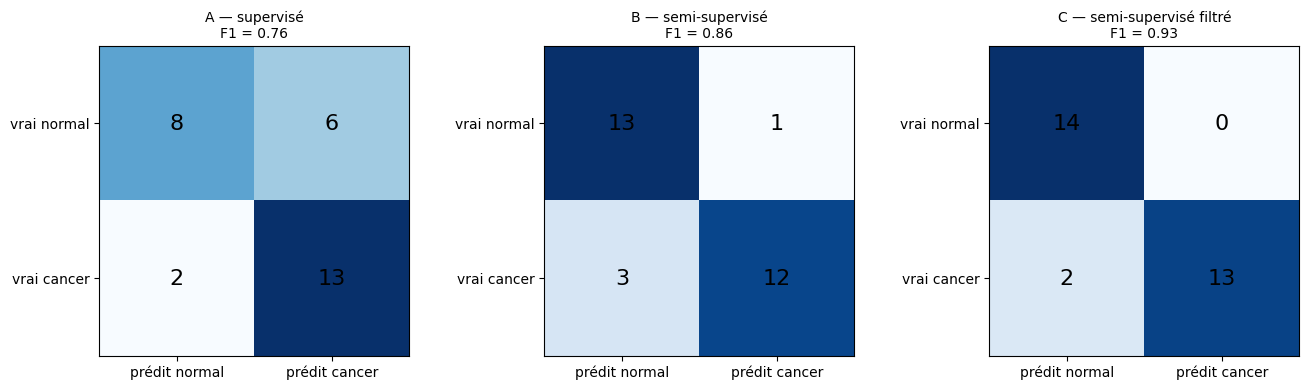

In [15]:
fig, axes = plt.subplots(1, len(resultats_test), figsize=(4.5 * len(resultats_test), 4))
for ax, (nom, scores) in zip(axes, resultats_test.items()):
    matrice = confusion_matrix(scores["vrais"], (scores["probas"] >= 0.5).astype(int))
    ax.imshow(matrice, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, matrice[i, j], ha="center", va="center", fontsize=16)
    ax.set_xticks([0, 1], ["prédit normal", "prédit cancer"])
    ax.set_yticks([0, 1], ["vrai normal", "vrai cancer"])
    ax.set_title(f"{nom}\nF1 = {scores['f1']:.2f}", fontsize=10)
plt.tight_layout()
plt.show()

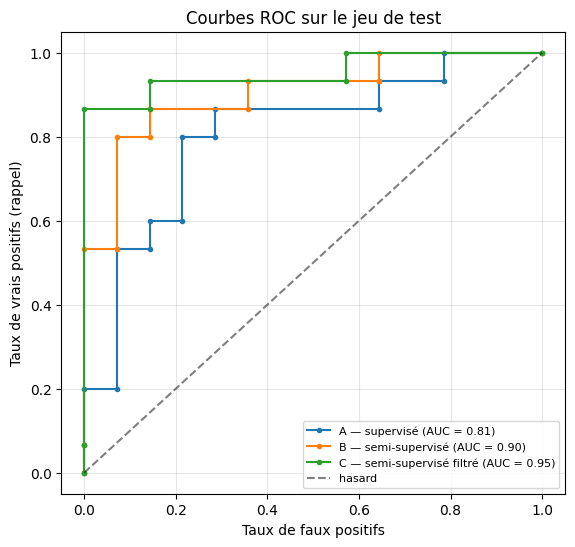

In [16]:
fig, ax = plt.subplots(figsize=(6.5, 6))
for nom, scores in resultats_test.items():
    fpr, tpr, _ = roc_curve(scores["vrais"], scores["probas"])
    ax.plot(fpr, tpr, marker=".", label=f"{nom} (AUC = {scores['auc']:.2f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="hasard")
ax.set_xlabel("Taux de faux positifs")
ax.set_ylabel("Taux de vrais positifs (rappel)")
ax.set_title("Courbes ROC sur le jeu de test")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.show()

Meilleur modèle : C — semi-supervisé filtré — 2 erreurs sur 29 images de test


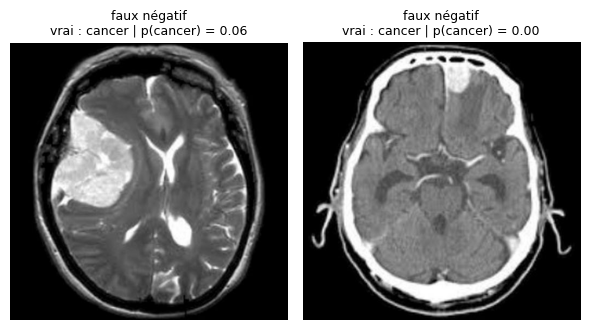

,path,label,prediction,proba_cancer
4,avec_labels/cancer/7e3f6acd-c9cc-440e-ba01-fed...,cancer,normal,0.058557
6,avec_labels/cancer/9973120d-7335-43da-bd9b-3c6...,cancer,normal,0.001732


In [17]:
# Erreurs du meilleur modèle : quelles images sont mal classées, et dans quel sens ?
meilleur_nom = max(resultats_test, key=lambda nom: resultats_test[nom]["f1"])
scores = resultats_test[meilleur_nom]
predictions = (scores["probas"] >= 0.5).astype(int)

erreurs = fort_test.copy()
erreurs["proba_cancer"] = scores["probas"]
erreurs["prediction"] = np.where(predictions == 1, "cancer", "normal")
erreurs = erreurs[erreurs["prediction"] != erreurs["label"]]

print(f"Meilleur modèle : {meilleur_nom} — {len(erreurs)} erreurs sur {len(fort_test)} images de test")

if len(erreurs):
    fig, axes = plt.subplots(1, len(erreurs), figsize=(3 * len(erreurs), 3.6), squeeze=False)
    for ax, (_, ligne) in zip(axes[0], erreurs.iterrows()):
        ax.imshow(Image.open(DATA_DIR / ligne["path"]), cmap="gray")
        type_erreur = "faux négatif" if ligne["label"] == "cancer" else "faux positif"
        ax.set_title(f"{type_erreur}\nvrai : {ligne['label']} | p(cancer) = {ligne['proba_cancer']:.2f}",
                     fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

erreurs[["path", "label", "prediction", "proba_cancer"]]

## 12. Le compromis faux négatifs

**C'est le point décisif de ce projet.** Les deux erreurs restantes du meilleur modèle sont des **faux négatifs** : deux tumeurs déclarées saines. En contexte médical, c'est l'erreur à éviter en priorité. Un faux positif conduit un radiologue à vérifier une image et à écarter l'alerte en quelques secondes ; un faux négatif renvoie un patient chez lui avec une tumeur non détectée.

Deux leviers permettent de déplacer ce compromis, et on les teste tous les deux.

**Levier 1 — pondérer la fonction de perte.** Pendant l'entraînement, on déclare qu'une erreur sur une image cancéreuse coûte 3 fois plus cher qu'une erreur sur une image saine. Le modèle apprend donc à préférer l'excès de prudence. C'est un réglage *interne*, qui change les poids appris.

**Levier 2 — abaisser le seuil de décision.** Le modèle produit une probabilité ; c'est nous qui fixons à partir de quelle valeur on déclare « cancer ». Le seuil de 0,5 n'est qu'une convention. L'abaisser revient à accepter plus d'alertes pour manquer moins de tumeurs. C'est un réglage *externe*, applicable après coup, sans réentraîner.

In [ ]:
POIDS_CLASSES = [1.0, 3.0]   # [normal, cancer] : une tumeur manquée coûte 3 fois plus cher

torch.manual_seed(SEED)
modele_pondere = PetitCNN().to(device)
modele_pondere.load_state_dict(poids_C0)      # même point de départ que le modèle C

with chrono("Entraînement — C pondéré (faux négatifs pénalisés)"):
    entrainer(modele_pondere,
              MRIDataset(sous_train, "label", transform_train),
              MRIDataset(sous_val, "label", transform_eval),
              poids_classes=POIDS_CLASSES, **MEILLEURS_HP)

vrais_p, probas_p = predire(modele_pondere, test_ds)
resultats_test["C pondéré"] = {**metriques(vrais_p, probas_p), "probas": probas_p, "vrais": vrais_p}
modeles_finaux["C pondéré"] = modele_pondere

pd.DataFrame({
    nom: {cle: valeur for cle, valeur in scores.items() if cle in ["accuracy", "f1", "auc"]}
    for nom, scores in resultats_test.items()
}).T.round(3)

**Le balayage du seuil.** Pour chaque valeur possible du seuil, on compte les tumeurs détectées, les tumeurs manquées et les fausses alertes. Le tableau donne le prix exact de chaque gain de sécurité.

In [ ]:
def balayer_seuil(vrais, probas, seuils=np.arange(0.05, 0.96, 0.05)):
    """Pour chaque seuil : combien de tumeurs détectées, manquées, et de fausses alertes."""
    lignes = []
    for seuil in seuils:
        predictions = (probas >= seuil).astype(int)
        vp = int(((predictions == 1) & (vrais == 1)).sum())    # tumeurs détectées
        fn = int(((predictions == 0) & (vrais == 1)).sum())    # tumeurs manquées
        fp = int(((predictions == 1) & (vrais == 0)).sum())    # fausses alertes
        lignes.append({
            "seuil": round(seuil, 2),
            "tumeurs détectées": vp,
            "tumeurs manquées": fn,
            "fausses alertes": fp,
            "rappel": vp / (vp + fn) if vp + fn else np.nan,
            "précision": vp / (vp + fp) if vp + fp else np.nan,
            "f1": f1_score(vrais, predictions, zero_division=0),
        })
    return pd.DataFrame(lignes)


nom_reference = max(resultats_test, key=lambda nom: resultats_test[nom]["auc"])
reference = resultats_test[nom_reference]
balayage = balayer_seuil(reference["vrais"], reference["probas"])

print(f"Modèle analysé : {nom_reference} (la meilleure AUC, donc le meilleur classement)")
balayage.round(3)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(balayage["seuil"], balayage["rappel"], marker="o", label="rappel (tumeurs détectées)")
axes[0].plot(balayage["seuil"], balayage["précision"], marker="o", label="précision")
axes[0].plot(balayage["seuil"], balayage["f1"], marker="o", label="F1")
axes[0].axvline(0.5, color="grey", linestyle="--", label="seuil par défaut")
axes[0].set_xlabel("Seuil de décision")
axes[0].set_title(f"Métriques selon le seuil — {nom_reference}")
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8)

axes[1].plot(balayage["seuil"], balayage["tumeurs manquées"], marker="o", color="tab:red",
             label="tumeurs manquées (faux négatifs)")
axes[1].plot(balayage["seuil"], balayage["fausses alertes"], marker="o", color="tab:orange",
             label="fausses alertes (faux positifs)")
axes[1].axvline(0.5, color="grey", linestyle="--")
axes[1].set_xlabel("Seuil de décision")
axes[1].set_ylabel("Nombre d'images (sur 29)")
axes[1].set_title("Le prix de la prudence")
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

**Le point de fonctionnement retenu.** On cherche le seuil le plus élevé qui ne laisse passer **aucune tumeur**, ou au pire une seule. Le garder aussi élevé que possible limite les fausses alertes ; l'abaisser davantage n'apporterait plus rien en sécurité.

In [ ]:
candidats = balayage[balayage["tumeurs manquées"] <= 1]
SEUIL_RETENU = candidats["seuil"].max() if len(candidats) else 0.5
ligne_retenue = balayage[balayage["seuil"] == SEUIL_RETENU].iloc[0]

comparaison_seuil = pd.DataFrame([
    balayage[balayage["seuil"] == 0.50].iloc[0].rename("seuil 0,50 (défaut)"),
    ligne_retenue.rename(f"seuil {SEUIL_RETENU:.2f} (retenu)"),
])
comparaison_seuil.round(3)

## 13. Une autre approche : ResNet + classifieur

Jusqu'ici, le CNN apprend **à partir de zéro**. L'autre grande façon de faire, c'est le **transfer learning** : réutiliser un réseau déjà entraîné sur des millions d'images, geler ses poids, et n'apprendre qu'un classifieur sur les représentations qu'il produit.

C'est exactement ce qui a servi aux étapes 2 et 3 pour le clustering. On le teste ici comme **méthode de classification à part entière**, pour la comparer au petit CNN maison :

| | Petit CNN maison | ResNet50 + classifieur |
| --- | --- | --- |
| Ce qui est appris | Tout, depuis zéro (93 378 paramètres) | Uniquement le classifieur ; ResNet reste gelé |
| Ce qu'il sait au départ | Rien | À reconnaître contours, textures et formes, appris sur 1,2 million d'images |
| Coût | Un entraînement complet par modèle | Une seule extraction, puis des classifieurs quasi instantanés |

Le classifieur utilisé est une **régression logistique**, volontairement simple : s'il suffit, c'est que les embeddings de ResNet portent déjà l'information utile.

On chronomètre l'extraction : c'est elle qui servira à estimer le coût du passage à l'échelle.

In [ ]:
from torchvision import models

# Preprocessing attendu par ResNet : 3 canaux, 224x224, normalisation ImageNet
transform_resnet = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


# Le réseau n'est chargé qu'une fois : le recharger fausserait le temps mesuré
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
resnet.fc = nn.Identity()              # on retire la couche de classification ImageNet
resnet = resnet.eval().to(device)
for parametre in resnet.parameters():
    parametre.requires_grad = False    # couches gelées


@torch.no_grad()
def extraire_embeddings(df, batch_size=64):
    """Fait passer les images dans ResNet50 gelé et renvoie un vecteur de 2 048 valeurs par image."""
    dataset = MRIDataset(df, df.columns[df.columns.isin(["label", "label_faible"])][0], transform_resnet)
    sorties = [resnet(x.to(device)).cpu() for x, _ in DataLoader(dataset, batch_size=batch_size)]
    return torch.cat(sorties).numpy()


with chrono(f"Extraction ResNet50 ({len(fort_train) + len(fort_test) + len(faibles)} images)"):
    emb_train = extraire_embeddings(fort_train)
    emb_test = extraire_embeddings(fort_test)
    emb_faibles = extraire_embeddings(faibles)

print(f"train {emb_train.shape} | test {emb_test.shape} | faibles {emb_faibles.shape}")

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

y_train_fort = (fort_train["label"] == "cancer").astype(int).values
y_test_fort = (fort_test["label"] == "cancer").astype(int).values
y_faibles = (faibles["label_faible"] == "cancer").astype(int).values

def classifieur():
    return make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, random_state=SEED))

# D1 — entraîné sur les 67 images fortes, évalué en validation croisée sur les mêmes plis
decoupage = StratifiedKFold(n_splits=N_PLIS, shuffle=True, random_state=SEED)
scores_cv = []
for idx_tr, idx_val in decoupage.split(emb_train, y_train_fort):
    modele = classifieur().fit(emb_train[idx_tr], y_train_fort[idx_tr])
    probas = modele.predict_proba(emb_train[idx_val])[:, 1]
    scores_cv.append(metriques(y_train_fort[idx_val], probas))
scores_cv = pd.DataFrame(scores_cv)

with chrono("Entraînement — ResNet + classifieur (67 images fortes)"):
    modele_D1 = classifieur().fit(emb_train, y_train_fort)
probas_D1 = modele_D1.predict_proba(emb_test)[:, 1]
resultats_test["D — ResNet + classifieur"] = {
    **metriques(y_test_fort, probas_D1), "probas": probas_D1, "vrais": y_test_fort}

# D2 — entraîné sur les 1 214 labels faibles, sans aucun label humain
with chrono("Entraînement — ResNet + classifieur (labels faibles)"):
    modele_D2 = classifieur().fit(emb_faibles, y_faibles)
probas_D2 = modele_D2.predict_proba(emb_test)[:, 1]
resultats_test["D0 — ResNet + classifieur, labels faibles"] = {
    **metriques(y_test_fort, probas_D2), "probas": probas_D2, "vrais": y_test_fort}

print(f"Validation croisée D : F1 = {scores_cv['f1'].mean():.3f} ± {scores_cv['f1'].std():.3f}")
pd.DataFrame({
    "D — sur les 67 images fortes": resultats_test["D — ResNet + classifieur"],
    "D0 — sur les labels faibles": resultats_test["D0 — ResNet + classifieur, labels faibles"],
}).T[["accuracy", "f1", "auc"]].round(3)

## 14. Influence de la taille de batch

La taille de batch, c'est le nombre d'images vues avant chaque mise à jour des poids. On balaie volontairement des valeurs **extrêmes**, de 4 à 128, pour rendre l'effet visible :

- **Batch très petit** : beaucoup de mises à jour, chacune calculée sur peu d'images, donc un gradient très bruité. L'entraînement est lent et instable, mais ce bruit aide parfois à s'échapper d'un minimum local.
- **Batch très grand** : peu de mises à jour, chacune très fiable. C'est rapide sur GPU, mais avec 67 images d'entraînement, un batch de 128 signifie **une seule mise à jour par epoch** : le modèle apprend à peine.

Chaque valeur est évaluée par validation croisée, et **chronométrée**, pour montrer le compromis entre performance et temps de calcul.

In [ ]:
tailles_batch = [4, 8, 16, 32, 64, 128]

lignes = []
for taille in tailles_batch:
    debut = time.perf_counter()
    scores = validation_croisee(poids_initiaux=poids_C0, batch_size=taille,
                                lr=MEILLEURS_HP["lr"], epochs=40)
    lignes.append({
        "batch": taille,
        "F1 moyen": scores["f1"].mean(),
        "F1 écart-type": scores["f1"].std(),
        "AUC moyenne": scores["auc"].mean(),
        "temps (s)": time.perf_counter() - debut,
    })

effet_batch = pd.DataFrame(lignes)
effet_batch.round(3)

In [ ]:
fig, ax_gauche = plt.subplots(figsize=(8, 4.5))

ax_gauche.errorbar(effet_batch["batch"], effet_batch["F1 moyen"], yerr=effet_batch["F1 écart-type"],
                   marker="o", capsize=4, color="tab:blue", label="F1 (validation croisée)")
ax_gauche.set_xscale("log", base=2)
ax_gauche.set_xlabel("Taille de batch (échelle logarithmique)")
ax_gauche.set_ylabel("F1", color="tab:blue")
ax_gauche.grid(alpha=0.3)

ax_droite = ax_gauche.twinx()   # second axe : le temps de calcul
ax_droite.plot(effet_batch["batch"], effet_batch["temps (s)"], marker="s", color="tab:red",
               linestyle="--", label="temps")
ax_droite.set_ylabel("Temps des 5 plis (s)", color="tab:red")

ax_gauche.set_title("Performance et temps selon la taille de batch")
fig.legend(loc="lower center", ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

## 15. Synthèse : performances, temps et ressources

Le tableau réunit toutes les approches testées : ce qu'elles coûtent, ce qu'elles rapportent, et surtout **combien de tumeurs elles manquent**.

In [ ]:
def compter_erreurs(scores, seuil=0.5):
    predictions = (scores["probas"] >= seuil).astype(int)
    return {
        "tumeurs manquées": int(((predictions == 0) & (scores["vrais"] == 1)).sum()),
        "fausses alertes": int(((predictions == 1) & (scores["vrais"] == 0)).sum()),
    }


synthese = pd.DataFrame({
    nom: {
        "accuracy": scores["accuracy"],
        "F1": scores["f1"],
        "AUC": scores["auc"],
        **compter_erreurs(scores),
    }
    for nom, scores in resultats_test.items()
}).T

synthese.round(3)

In [ ]:
# Temps mesurés à chaque étape
pd.Series(TEMPS, name="secondes").sort_values(ascending=False).round(1).to_frame()

## 16. Extrapolation au passage à l'échelle

Clara demande si **4 millions d'images peuvent être labellisées avec 5 000 €**, soit 0,00125 € par image, contre 0,20 € aujourd'hui (300 € pour 1 500 images).

Le raisonnement : notre chaîne ne demande **aucune annotation humaine** au-delà du petit jeu de référence. Son coût est donc essentiellement du **temps de calcul GPU**, qu'on vient de mesurer. On extrapole à partir du temps réel d'extraction par image, puisque c'est l'étape dominante à grande échelle : l'entraînement, lui, ne se fait qu'une fois.

Les hypothèses de prix sont indicatives et à ajuster selon le fournisseur.

In [ ]:
N_IMAGES_CIBLE = 4_000_000
BUDGET = 5_000          # euros
PRIX_GPU_HEURE = 0.35   # ordre de grandeur d'un GPU T4 chez un fournisseur cloud, en euros

cle_extraction = next(cle for cle in TEMPS if cle.startswith("Extraction ResNet50"))
n_images_mesurees = len(fort_train) + len(fort_test) + len(faibles)
temps_par_image = TEMPS[cle_extraction] / n_images_mesurees

heures = N_IMAGES_CIBLE * temps_par_image / 3600
cout_calcul = heures * PRIX_GPU_HEURE

pd.Series({
    "temps mesuré par image (s)": round(temps_par_image, 4),
    "heures GPU pour 4 M d'images": round(heures, 1),
    "coût de calcul estimé (€)": round(cout_calcul, 2),
    "part du budget de 5 000 €": f"{cout_calcul / BUDGET:.1%}",
    "budget restant pour l'annotation (€)": round(BUDGET - cout_calcul, 2),
}, name="passage à l'échelle").to_frame()

## 17. Sauvegarde des résultats

In [18]:
synthese.to_csv(OUTPUT_DIR / "synthese_modeles.csv")
effet_batch.to_csv(OUTPUT_DIR / "effet_taille_batch.csv", index=False)
balayage.to_csv(OUTPUT_DIR / "balayage_seuil.csv", index=False)
pd.Series(TEMPS).to_csv(OUTPUT_DIR / "temps_execution.csv")
tableau_test.to_csv(OUTPUT_DIR / "resultats_test.csv")
resume_cv.to_csv(OUTPUT_DIR / "resultats_validation_croisee.csv")
resultats_grille.to_csv(OUTPUT_DIR / "resultats_hyperparametres.csv", index=False)
torch.save({nom: model.state_dict() for nom, model in modeles_finaux.items()},
           OUTPUT_DIR / "modeles_finaux.pt")

print("Résultats sauvegardés dans", OUTPUT_DIR)

Résultats sauvegardés dans /content/drive/MyDrive/BrainScanAI/outputs


## 18. Observations et definition of done

### Les résultats

| Modèle | F1 en validation croisée (5 plis) | Test : accuracy | Test : F1 | Test : AUC |
| --- | --- | --- | --- | --- |
| **A — supervisé** | 0,765 ± 0,062 | 0,724 | 0,765 | 0,810 |
| **B — semi-supervisé** | 0,925 ± 0,068 | 0,862 | 0,857 | 0,905 |
| **C — semi-supervisé filtré** | 0,920 ± 0,025 | **0,931** | **0,929** | 0,952 |
| **B0 — faible seul** | — | 0,793 | 0,800 | 0,905 |

### Ce qu'on en retient

**1. Le semi-supervisé bat nettement le supervisé.** En validation croisée, le F1 passe de 0,765 à 0,925, soit un gain de 0,16. L'écart est plus de deux fois supérieur aux écarts-types (0,06), donc il ne s'explique pas par le hasard du découpage. La réponse à la question du projet est donc oui : **les 1 214 images sans annotation humaine ont servi à quelque chose.**

**2. Un modèle sans aucun label humain atteint déjà 0,80 de F1.** C'est le modèle B0, entraîné uniquement sur les étiquettes produites par le clustering. Il fait mieux que le modèle supervisé entraîné sur les 67 annotations d'experts (0,765). Autrement dit, **1 214 étiquettes imparfaites valent mieux que 67 étiquettes parfaites** pour ce problème.

**3. Le modèle supervisé souffre du manque de données.** Trois des quatre configurations d'hyperparamètres testées donnent un F1 de 0,687 pour une accuracy de 0,523 : le modèle prédit « cancer » presque partout, ce qui est le comportement typique d'un réseau qui n'arrive pas à apprendre. Avec 67 images, il est à la limite de ce qui est faisable.

**4. Filtrer les labels faibles stabilise l'apprentissage.** Le modèle C, préentraîné sur les 70 % de labels les plus sûrs (850 images au lieu de 1 214), obtient le meilleur score sur le test et surtout un **écart-type deux fois plus faible** en validation croisée (0,025 contre 0,068). Moins de données, mais plus propres : c'est exactement ce que prédit le cours sur la pseudo-labellisation, qui met en garde contre la propagation des erreurs.

**5. Les erreurs restantes sont les plus graves.** Le modèle C se trompe sur 2 images des 29 du test, et ce sont **deux faux négatifs**, c'est-à-dire deux tumeurs manquées. Il ne produit aucune fausse alerte. Son rappel sur la classe cancer est donc de 13/15, soit 0,867, pour une précision de 1,00. Pour un usage médical, ce compromis est le mauvais sens : mieux vaudrait accepter quelques fausses alertes, qu'un radiologue lèverait en quelques secondes, plutôt que de laisser passer une tumeur. Avec une AUC de 0,952, **abaisser le seuil de décision sous 0,5 permettrait de récupérer des tumeurs au prix de quelques faux positifs**. C'est le réglage à discuter avec le métier.

### La definition of done

| Critère fixé à l'avance | Résultat | Atteint |
| --- | --- | --- |
| Le semi-supervisé fait mieux que le supervisé en F1 | 0,925 contre 0,765 en validation croisée | Oui |
| L'écart dépasse l'incertitude de mesure | Écart de 0,16, pour des écarts-types de 0,06 | Oui |
| Rappel sur la classe cancer d'au moins 0,80 | 0,867 pour le modèle C | Oui |
| Aucune fuite entre jeu faible, train et test | Vérifiée par `assert` aux étapes 2, 3 et 4 | Oui |

**L'objectif est atteint.** Compte tenu de la petite taille du jeu de données, ces résultats sont prometteurs.

### Les limites à annoncer

- **Le jeu de test ne compte que 29 images.** Une erreur de plus ou de moins déplace l'accuracy de 3,5 points. Les mêmes modèles entraînés en local, sur un autre matériel, donnaient un F1 de 0,903 pour B et 0,897 pour C : le classement entre B et C n'est donc **pas stable**, même si tous deux dépassent largement A.
- **Le biais identifié à l'étape 3 subsiste.** Les labels faibles séparent en partie les plans de coupe et les séquences plutôt que les tumeurs. Les rotations, retournements et variations de luminosité appliqués à l'entraînement atténuent ce biais, mais ne le suppriment pas.
- **Les métriques du semi-supervisé dépendent d'un clustering imparfait.** La qualité des labels faibles, estimée à 88 %, plafonne mécaniquement ce que le préentraînement peut apporter.
- **Aucune validation clinique.** Les labels sont ceux de deux radiologues partenaires, sans double lecture ni arbitrage.